<div style="
  background: linear-gradient(145deg, #1a0b08, #2d1310);
  border: 4px solid transparent;
  border-radius: 14px;
  padding: 18px 22px;
  margin: 12px 0;
  font-size: 26px;
  font-weight: 600;
  color: #fff8f6;
  box-shadow: 0 6px 14px rgba(0,0,0,0.3);
  background-clip: padding-box;
  position: relative;
">
  <div style="
    position: absolute;
    inset: 0;
    padding: 4px;
    border-radius: 14px;
    background: linear-gradient(90deg, #ff7b00, #ff0054, #9d0208);
    -webkit-mask: 
      linear-gradient(#fff 0 0) content-box, 
      linear-gradient(#fff 0 0);
    -webkit-mask-composite: xor;
    mask-composite: exclude;
    pointer-events: none;
  "></div>
  
  <b>Making Your Model Learn Addition!</b>
  <br>
  <span style="color:#ffb5a7; font-size: 18px;">(Simple Recurrent Neural Network with Keras)</span>
</div>


---

# Table of Contents 

1. [Task 1: Introduction](#task-1)
2. [Task 2: Generate Data](#task-2)
3. [Task 3: Create the Model](#task-3)
4. [Task 4: Vectorize and De-Vectorize Data](#task-4)
5. [Task 5: Create Dataset](#task-5)
6. [Task 6: Training the Model](#task-6)
   - 6.1 [Test Set Predictions](#task-6-1)
   - 6.2 [Interactive Quiz, Missing Code & Arithmetic Puzzle](#task-6-2)

---


<a id="task-1"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 1: Introduction</span>

Given the string "54+7", the model should return a prediction: "61".


In [1]:
# Modern, learner-friendly imports
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, RepeatVector, TimeDistributed, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, LambdaCallback, History
import matplotlib.pyplot as plt
from termcolor import colored

# Display framework version for transparency
print('Using TensorFlow version:', tf.__version__)

Using TensorFlow version: 2.20.0


<a id="task-2"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 2: Generate Data</span>

___
Note: If you are starting the notebook from this task, you can run cells from all previous tasks in the kernel by going to the top menu and then selecting Kernel > Restart and Run All
___


In [2]:
all_chars = '0123456789+'

In [3]:
num_features = len(all_chars)

char_to_index = dict((c, i) for i, c in enumerate(all_chars))
index_to_char = dict((i, c) for i, c in enumerate(all_chars))

print('Number of features:', num_features)

Number of features: 11


In [4]:
def generate_data():
    first_num = np.random.randint(low=0,high=100)
    second_num = np.random.randint(low=0,high=100)
    example = str(first_num) + '+' + str(second_num)
    label = str(first_num+second_num)
    return example, label

generate_data()

('48+16', '64')

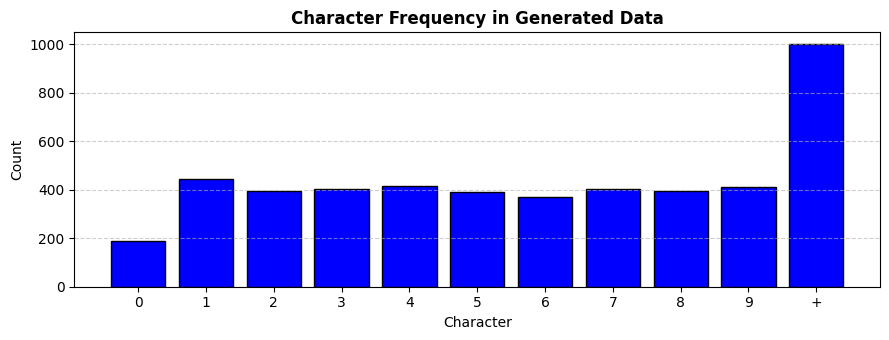

In [5]:
# Character frequency in 1,000 generated addition samples
sample_equations = [generate_data()[0] for _ in range(1000)]
char_counts = {c: 0 for c in all_chars}
for eq in sample_equations:
    for c in eq:
        char_counts[c] += 1

plt.figure(figsize=(9, 3.5))
plt.bar(list(char_counts.keys()), list(char_counts.values()), color='blue', edgecolor='black')
plt.title('Character Frequency in Generated Data', fontsize=12, fontweight='bold')
plt.xlabel('Character', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


<a id="task-3"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 3: Create the Model</span>

___
Note: If you are starting the notebook from this task, you can run cells from all previous tasks in the kernel by going to the top menu and then selecting Kernel > Restart and Run All
___

Consider these two reviews:

Review 1: This movie is not terrible at all.

Review 2: This movie is pretty decent.


In [6]:
hidden_units = 128
max_time_steps = 5

model = Sequential([
    SimpleRNN(hidden_units, input_shape=(None, num_features)),
    RepeatVector(max_time_steps),
    SimpleRNN(hidden_units, return_sequences=True),
    TimeDistributed(Dense(num_features, activation='softmax'))
    ])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 5, 128)         │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 5, 11)          │         1,419 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,235 (204.04 KB)

 Trainable params: 52,235 (204.04 KB)

 Non-trainable params: 0 (0.00 B)

<a id="task-4"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 4: Vectorize and De-Vectorize Data</span>

___
Note: If you are starting the notebook from this task, you can run cells from all previous tasks in the kernel by going to the top menu and then selecting Kernel > Restart and Run All
___


In [7]:
def vectorize_example(example, label):
    
    x = np.zeros((max_time_steps, num_features))
    y = np.zeros((max_time_steps, num_features))
    
    diff_x = max_time_steps - len(example)
    diff_y = max_time_steps - len(label)
    
    for i, c in enumerate(example):
        x[diff_x+i, char_to_index[c]] = 1
    for i in range(diff_x):
        x[i, char_to_index['0']] = 1
    for i, c in enumerate(label):
        y[diff_y+i, char_to_index[c]] = 1
    for i in range(diff_y):
        y[i, char_to_index['0']] = 1
        
    return x, y

e, l = generate_data()
print('Text Example and Label:', e, l)
x, y = vectorize_example(e, l)
print('Vectorized Example and Label Shapes:', x.shape, y.shape)

Text Example and Label: 76+92 168
Vectorized Example and Label Shapes: (5, 11) (5, 11)


In [8]:
def devectorize_example(example):
    result = [index_to_char[np.argmax(vec)] for i, vec in enumerate(example)]
    return ''.join(result)

devectorize_example(x)

'76+92'

In [9]:
devectorize_example(y)

'00168'

<a id="task-5"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 5: Create Dataset</span>

___
Note: If you are starting the notebook from this task, you can run cells from all previous tasks in the kernel by going to the top menu and then selecting Kernel > Restart and Run All
___


In [10]:
def create_dataset(num_examples=2000):

    x_train = np.zeros((num_examples, max_time_steps, num_features))
    y_train = np.zeros((num_examples, max_time_steps, num_features))

    for i in range(num_examples):
        e, l = generate_data()
        x, y = vectorize_example(e, l)
        x_train[i] = x
        y_train[i] = y
    
    return x_train, y_train

x_train, y_train = create_dataset(20000)
print(x_train.shape, y_train.shape)

(20000, 5, 11) (20000, 5, 11)


In [11]:
devectorize_example(x_train[0])

'86+72'

In [12]:
devectorize_example(y_train[0])

'00158'

<a id="task-6"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 6: Training the Model</span>

___
Note: If you are starting the notebook from this task, you can run cells from all previous tasks in the kernel by going to the top menu and then selecting Kernel > Restart and Run All
___

Please note that the hyper-parameters are a little different and the size of the dataset is different compared to the hands on project example. This model should easily get to 100% accuracy.


In [13]:
simple_logger = LambdaCallback(
    on_epoch_end=lambda e, l: print('{:.2f}'.format(l['val_accuracy']), end=' _ ')
    )
early_stopping = EarlyStopping(monitor='val_loss', patience=10)

history = model.fit(x_train, y_train, epochs=100, validation_split=0.2, verbose=False,
         batch_size=1024, callbacks=[simple_logger, early_stopping])

0.61 _ 0.62 _ 0.63 _ 0.65 _ 0.66 _ 0.67 _ 0.69 _ 0.72 _ 0.73 _ 0.75 _ 0.76 _ 0.78 _ 0.78 _ 0.79 _ 0.79 _ 0.81 _ 0.81 _ 0.81 _ 0.81 _ 0.83 _ 0.83 _ 0.85 _ 0.87 _ 0.87 _ 0.90 _ 0.92 _ 0.93 _ 0.94 _ 0.95 _ 0.96 _ 0.96 _ 0.97 _ 0.97 _ 0.97 _ 0.98 _ 0.98 _ 0.98 _ 0.98 _ 0.99 _ 0.98 _ 0.99 _ 0.99 _ 0.99 _ 0.99 _ 0.99 _ 0.99 _ 0.99 _ 0.99 _ 1.00 _ 0.99 _ 1.00 _ 1.00 _ 1.00 _ 1.00 _ 1.00 _ 1.00 _ 1.00 _ 1.00 _ 1.00 _ 1.00 _ 1.00 _ 1.00 _ 1.00 _ 1.00 _ 1.00 _ 1.00 _ 1.00 _ 1.00 _ 1.00 _ 1.00 _ 1.00 _ 1.00 _ 1.00 _ 1.00 _ 1.00 _ 1.00 _ 1.00 _ 1.00 _ 0.84 _ 0.95 _ 0.99 _ 1.00 _ 1.00 _ 1.00 _ 1.00 _ 1.00 _ 1.00 _ 

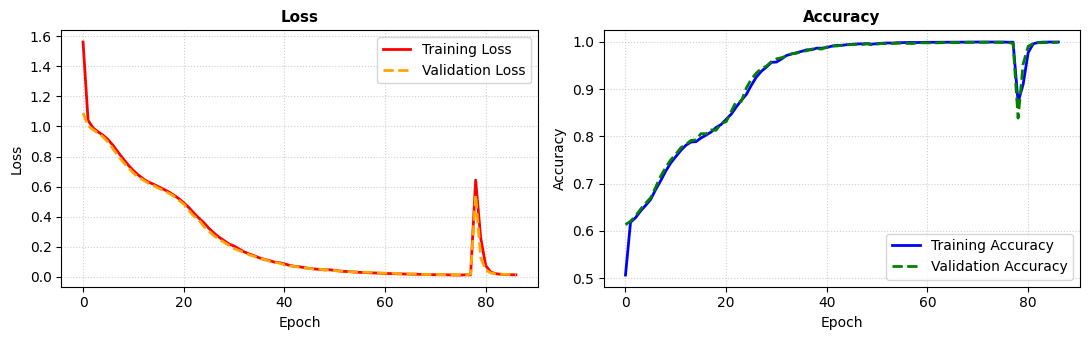

In [14]:
# Training and validation performance over epochs
plt.figure(figsize=(11, 3.5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], color='red', linewidth=2, label='Training Loss')
plt.plot(history.history['val_loss'], color='orange', linewidth=2, linestyle='--', label='Validation Loss')
plt.title('Loss', fontsize=11, fontweight='bold')
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], color='blue', linewidth=2, label='Training Accuracy')
plt.plot(history.history['val_accuracy'], color='green', linewidth=2, linestyle='--', label='Validation Accuracy')
plt.title('Accuracy', fontsize=11, fontweight='bold')
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Accuracy', fontsize=10)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


<a id="task-6-1"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">6.1 Test Set Predictions</span>

Create a test set and look at some predictions:


In [15]:
x_test, y_test = create_dataset(num_examples=20)
preds = model.predict(x_test)
full_seq_acc = 0

for i, pred in enumerate(preds):
    pred_str = devectorize_example(pred)
    y_test_str = devectorize_example(y_test[i])
    x_test_str = devectorize_example(x_test[i])
    col = 'green' if pred_str == y_test_str else 'red'
    full_seq_acc += 1/len(preds) * int(pred_str == y_test_str)
    outstring = 'Input: {}, Out: {}, Pred: {}'.format(x_test_str, y_test_str, pred_str)
    print(colored(outstring, col))
print('\nFull sequence accuracy: {:.3f} %'.format(100 * full_seq_acc))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
Input: 77+17, Out: 00094, Pred: 00094
Input: 15+68, Out: 00083, Pred: 00083
Input: 014+9, Out: 00023, Pred: 00023
Input: 060+5, Out: 00065, Pred: 00065
Input: 42+14, Out: 00056, Pred: 00056
Input: 80+40, Out: 00120, Pred: 00120
Input: 22+42, Out: 00064, Pred: 00064
Input: 19+80, Out: 00099, Pred: 00099
Input: 48+33, Out: 00081, Pred: 00081
Input: 72+37, Out: 00109, Pred: 00109
Input: 04+77, Out: 00081, Pred: 00081
Input: 044+3, Out: 00047, Pred: 00047
Input: 004+6, Out: 00010, Pred: 00010
Input: 51+60, Out: 00111, Pred: 00111
Input: 91+72, Out: 00163, Pred: 00163
Input: 18+83, Out: 00101, Pred: 00101
Input: 60+47, Out: 00107, Pred: 00107
Input: 90+10, Out: 00100, Pred: 00100
Input: 93+31, Out: 00124, Pred: 00124
Input: 98+66, Out: 00164, Pred: 00164

Full sequence accuracy: 100.000 %


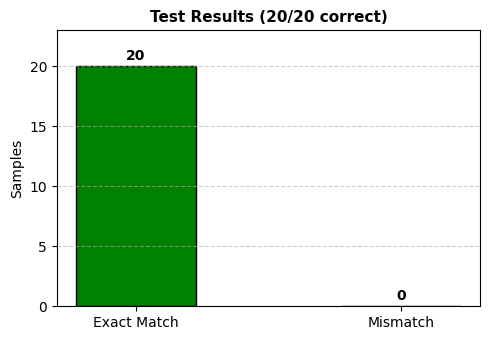

In [16]:
# Summary of test prediction accuracy
eval_labels = ['Exact Match', 'Mismatch']
num_test = len(preds)
correct = sum(1 for i in range(num_test) if devectorize_example(preds[i]) == devectorize_example(y_test[i]))
incorrect = num_test - correct

plt.figure(figsize=(5, 3.5))
bars = plt.bar(eval_labels, [correct, incorrect], color=['green', 'red'], width=0.45, edgecolor='black')
for b in bars:
    y = b.get_height()
    plt.text(b.get_x() + b.get_width()/2.0, y + 0.3, int(y), ha='center', va='bottom', fontweight='bold')

plt.title(f'Test Results ({correct}/{num_test} correct)', fontsize=11, fontweight='bold')
plt.ylabel('Samples', fontsize=10)
plt.ylim(0, num_test + 3)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


<a id="task-6-2"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">6.2 Interactive Quiz, Missing Code & Arithmetic Puzzle</span>

Test your understanding of sequence-to-sequence learning with Recurrent Neural Networks through this interactive quiz, fill in the missing code challenge, and custom arithmetic puzzle tester.


### Concept Check: Recurrent Neural Network Foundations

**1. Why is `RepeatVector(5)` placed between the Encoder and Decoder RNNs?**
- **A)** To duplicate the input dataset 5 times for data augmentation
- **B)** To repeat the 2D encoder state across all 5 time steps so the decoder can produce a sequence
- **C)** To increase the learning rate of the optimizer
- **D)** To convert character indices into floats

<details>
<summary><b>View Answer & Explanation</b></summary>

> **Correct Answer: B**  
> The first `SimpleRNN` returns a single summary vector of shape `(batch, hidden_units)`. `RepeatVector(5)` replicates this representation 5 times along the time axis, providing the decoder with the temporal dimension it needs to generate characters step-by-step.
</details>

---

**2. What does `TimeDistributed(Dense(...))` do?**
- **A)** It applies the same output Dense layer to every time step independently
- **B)** It records the execution time per epoch
- **C)** It shuffles temporal sequences randomly
- **D)** It applies dropout at scheduled time intervals

<details>
<summary><b>View Answer & Explanation</b></summary>

> **Correct Answer: A**  
> `TimeDistributed` wraps the Dense layer so that identical weights and biases are used to classify the character at every position in the 5-step sequence.
</details>

---

**3. Why are all equations left-padded with `'0'` to length 5?**
- **A)** To make all numbers bigger
- **B)** Mini-batch training in deep learning requires uniform, rectangular tensor shapes
- **C)** Neural networks can only process strings of length 5
- **D)** It prevents the model from predicting negative values

<details>
<summary><b>View Answer & Explanation</b></summary>

> **Correct Answer: B**  
> Batch gradient descent requires all examples in a batch to share the exact same tensor shape `(batch_size, time_steps, features)`. Left-padding with `'0'` aligns variable-length numbers like `"5+3"` and `"42+19"` into a uniform 5-step representation.
</details>


In [17]:
# Exercise: 3-digit addition generator
# Generates pairs of 3-digit numbers (100 to 999) for testing sequence generalization

def generate_3digit_example():
    num1 = np.random.randint(100, 1000)
    num2 = np.random.randint(100, 1000)
    return f"{num1}+{num2}", str(num1 + num2)

# Test the generator
sample_eq, sample_ans = generate_3digit_example()
print(f"Generated: {sample_eq}  (Expected sum: {sample_ans})")


Generated: 272+700  (Expected sum: 972)


In [18]:
# Helper to test custom equations on our trained model
def predict_sum(equation_str):
    if '+' not in equation_str:
        return "Please provide an equation with '+' (e.g., '35+42')"
    
    diff = max_time_steps - len(equation_str)
    if diff < 0:
        return f"Equation too long (max {max_time_steps} chars)"
        
    x_input = np.zeros((1, max_time_steps, num_features))
    for i in range(diff):
        x_input[0, i, char_to_index['0']] = 1
    for i, c in enumerate(equation_str):
        if c in char_to_index:
            x_input[0, diff + i, char_to_index[c]] = 1
            
    pred = model.predict(x_input, verbose=0)[0]
    return devectorize_example(pred).lstrip('0') or '0'

# Test custom equations
test_cases = ['25+43', '10+15', '9+8', '60+39', '88+11']
for eq in test_cases:
    result = predict_sum(eq)
    expected = sum(map(int, eq.split('+')))
    status = 'PASS' if result == str(expected) else 'MISMATCH'
    print(f"{eq:<8} -> Model: {result:<5} | Expected: {expected:<5} [{status}]")


25+43    -> Model: 68    | Expected: 68    [PASS]
10+15    -> Model: 25    | Expected: 25    [PASS]
9+8      -> Model: 17    | Expected: 17    [PASS]
60+39    -> Model: 99    | Expected: 99    [PASS]
88+11    -> Model: 99    | Expected: 99    [PASS]
